# Visual Frame Baseline — Extended Data

Revised video-fake detection baseline over the current extended MAVOS-DD data and frozen splits.

**What this notebook answers.** Is the face/video generated? This is the *visual-only, video-fake* branch:

- Distinct from **audio spoof detection** (`src/train.py --modality audio`) which asks "is the speech synthetic?"
- Distinct from **audio-visual lip-sync consistency** (`src/train_lipsync.py`) which asks "does the audio match the mouth motion?"

The label used everywhere below is `video_label_binary` (never `audio_label_binary`).

**What it refactors from the coworker notebook** (`notebooks/legacy/2_Visual_models_full_dataset_original.ipynb`):

- Same deterministic linspace frame sampling (`NUM_FRAMES=20`).
- Same pretrained ImageNet backbone family (torchvision — EfficientNetB0 replaces the coworker's ResNet50 as the default; ResNet50 is available as an alternate).
- **Different splits.** The coworker used `sklearn.train_test_split(..., stratify=y)` inside the notebook. This version uses the frozen project splits from `data/derived/visual_speech_manifest_voice_split.csv` and never touches the `test` split.
- **Different labels.** The coworker labeled by source folder (`real=0`, `echomimic/memo=1`). This version reads `video_label_binary` directly from the manifest, which encodes the extended source set (`real=0`; `echomimic|memo|liveportrait|sonic=1`).

**Non-goals for this notebook.**

- No test-split evaluation. Test is locked.
- No canonical model artifact writes. Any output goes under gitignored `runs/` or `report/visual_frame_baseline/`.
- No random resplitting. The manifest's `split` column is authoritative.

## Configuration

In [12]:
from __future__ import annotations

import json
import os
import random
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

SEED = 42
NUM_FRAMES = 20
BATCH_SIZE_FRAMES = 64
NUM_EPOCHS = 5
LR = 1e-3
WEIGHT_DECAY = 1e-4

BACKBONE = "efficientnet_b0"  # or "resnet50"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

REPO_ROOT = Path(".").resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "src").exists(), f"cannot locate repo root from {REPO_ROOT}"

MANIFEST_PATH = REPO_ROOT / "data" / "derived" / "visual_speech_manifest_voice_split.csv"
RESULTS_DIR = REPO_ROOT / "report" / "visual_frame_baseline"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"device={DEVICE} backbone={BACKBONE} seed={SEED} frames_per_video={NUM_FRAMES}")
print(f"repo_root={REPO_ROOT}")
print(f"manifest={MANIFEST_PATH.relative_to(REPO_ROOT)} exists={MANIFEST_PATH.exists()}")

device=mps backbone=efficientnet_b0 seed=42 frames_per_video=20
repo_root=/Users/fgram-devai/Documents/Projects/Python/multimodal-dl-analysis-mavosDD
manifest=data/derived/visual_speech_manifest_voice_split.csv exists=True


## Manifest choice

The visual-speech manifest carries two row types:

- `pair_label == "matched_bonafide"` — one row per unique source video, `provider == "original"`, `video_label` filled in from the source folder.
- `pair_label == "generated_same_transcript"` — TTS pairings that reuse the same source video's frames but with synthetic audio. Same `source_video_id`, `video_label == "na"`.

For video-fake detection we only care about unique videos and their `video_label`, so we filter to `matched_bonafide` and read `video_label_binary` directly. This intentionally drops the TTS-pair rows (they don't add visual information) and also drops the `na` visual labels.

In [13]:
import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from src.common import LABEL_MAP

raw = pd.read_csv(MANIFEST_PATH, dtype=str)
print(f"manifest_rows={len(raw)}")
print("pair_label counts:")
print(raw["pair_label"].value_counts())

manifest = raw[raw["pair_label"] == "matched_bonafide"].copy()

# The manifest builder in src/data/build_speech_manifests.py::VIDEO_LABEL_BY_SOURCE
# only maps the pre-expansion folders (real/echomimic/memo). matched_bonafide rows
# from `liveportrait` and `sonic` therefore land with video_label="na" and an
# empty video_label_binary. Derive the label from source_folder via the
# authoritative 5-source src.common.LABEL_MAP instead of trusting the manifest.
unknown = sorted(set(manifest["source_folder"]) - set(LABEL_MAP))
assert not unknown, f"source_folder(s) not in LABEL_MAP: {unknown}"
manifest["video_label_binary"] = manifest["source_folder"].map(LABEL_MAP).astype(int)
print(f"\nfiltered_to_matched_bonafide_rows={len(manifest)}")
print("video_label_binary from LABEL_MAP:")
print(manifest["video_label_binary"].value_counts())

# Resolve video_path relative to REPO_ROOT so cwd doesn't matter.
manifest["video_path_resolved"] = manifest["video_path"].map(
    lambda p: str((REPO_ROOT / p).resolve())
)
missing = [p for p in manifest["video_path_resolved"] if not Path(p).exists()]
print(f"missing_video_files={len(missing)} / {len(manifest)}")
if missing[:3]:
    print("first few missing:", missing[:3])

manifest_rows=6367
pair_label counts:
pair_label
matched_bonafide             4149
generated_same_transcript    2218
Name: count, dtype: int64

filtered_to_matched_bonafide_rows=4149
video_label_binary from LABEL_MAP:
video_label_binary
0    2500
1    1649
Name: count, dtype: int64
missing_video_files=0 / 4149


## Guard cells

In [14]:
# Guard 1: no test rows survive downstream.
train_df = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_df = manifest[manifest["split"] == "val"].reset_index(drop=True)
banned = manifest[manifest["split"] == "test"]

assert len(banned) > 0, "manifest has no test rows — did the split column drift?"
print(f"train_rows={len(train_df)} val_rows={len(val_df)} test_rows_dropped={len(banned)}")
assert "test" not in set(train_df["split"]) | set(val_df["split"]), (
    "test rows leaked into train/val"
)

# Guard 2: both splits contain both labels.
for name, df in (("train", train_df), ("val", val_df)):
    labels = set(df["video_label_binary"].unique().tolist())
    assert labels == {0, 1}, f"{name} split missing a label: {labels}"

# Guard 3: label column is video_label_binary, not audio_label_binary.
label_col = "video_label_binary"
assert label_col in train_df.columns
assert train_df[label_col].dtype.kind in {"i", "u"}, train_df[label_col].dtype

# Guard 4: row counts by split, video label, and source folder.
print("\nRow counts (split x video_label_binary):")
print(pd.crosstab(manifest["split"], manifest["video_label_binary"]))

print("\nRow counts (split x source_folder):")
print(pd.crosstab(manifest["split"], manifest["source_folder"]))

train_rows=2904 val_rows=622 test_rows_dropped=623

Row counts (split x video_label_binary):
video_label_binary     0     1
split                         
test                 375   248
train               1750  1154
val                  375   247

Row counts (split x source_folder):
source_folder  echomimic  liveportrait  memo  real  sonic
split                                                    
test                  90            47    60   375     51
train                420           220   280  1750    234
val                   90            47    60   375     50


## Codec / resolution audit — the visual analog of the audio-codec shortcut

Before we spend compute on any classifier, we audit whether the raw video files themselves already give the label away through encoder metadata. This is the visual mirror of the audio-codec shortcut we already documented (`CLAUDE.md`: WavLM/HuBERT saturated at val ROC-AUC = 1.0 because TTS engines leave spectral fingerprints).

Sample ~20 videos per source folder, probe with `ffprobe`, print the distribution of `(width, height, codec, pix_fmt, fps)` per source. If every generator has a distinct signature that's different from real, a naive CNN trained on the raw pixel data will almost certainly learn the shortcut — not "does this face look generated".

In [15]:
import subprocess


def probe_video(path: str) -> dict:
    try:
        out = subprocess.run(
            ["ffprobe", "-v", "error", "-select_streams", "v:0",
             "-show_entries",
             "stream=width,height,codec_name,pix_fmt,r_frame_rate",
             "-of", "json", path],
            capture_output=True, text=True, timeout=15,
        )
        return json.loads(out.stdout)["streams"][0]
    except (subprocess.SubprocessError, KeyError, json.JSONDecodeError, IndexError) as exc:
        return {"error": str(exc)[:60]}


audit_sample = (
    manifest.groupby("source_folder", group_keys=False)
    .apply(lambda g: g.sample(min(20, len(g)), random_state=SEED))
)

audit_rows = []
for _, r in tqdm(list(audit_sample.iterrows()), desc="codec audit"):
    info = probe_video(r["video_path_resolved"])
    if "error" in info:
        audit_rows.append({"source_folder": r["source_folder"], "signature": f"ERROR:{info['error']}"})
        continue
    sig = (
        f"{info.get('width')}x{info.get('height')} "
        f"codec={info.get('codec_name')} "
        f"pix={info.get('pix_fmt')} "
        f"fps={info.get('r_frame_rate')}"
    )
    audit_rows.append({"source_folder": r["source_folder"], "signature": sig})

audit_df = pd.DataFrame(audit_rows)
print("Codec / resolution signatures per source folder:")
for src, group in audit_df.groupby("source_folder"):
    print(f"\n=== {src} (n={len(group)}) ===")
    for sig, count in group["signature"].value_counts().items():
        print(f"  {count:3d}x  {sig}")

n_signatures_per_source = audit_df.groupby("source_folder")["signature"].nunique()
shared_signatures = (
    audit_df.groupby("signature")["source_folder"].nunique()
    .loc[lambda s: s > 1]
)
print(f"\nDistinct signatures per source: {n_signatures_per_source.to_dict()}")
print(f"Signatures shared across ≥2 source folders: {len(shared_signatures)}")
if len(shared_signatures) == 0:
    print(
        "\n[SHORTCUT WARNING] No overlap between source folders. Any frame "
        "classifier will very likely pick up encoder / resolution artifacts "
        "instead of face-realism features. Treat downstream AUC skeptically."
    )

/var/folders/qt/j5239sh90fz_jf82j2dvbf2w0000gn/T/ipykernel_66829/3226007234.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(20, len(g)), random_state=SEED))


codec audit:   0%|          | 0/100 [00:00<?, ?it/s]

Codec / resolution signatures per source folder:

=== echomimic (n=20) ===
   20x  512x512 codec=h264 pix=yuv420p fps=24/1

=== liveportrait (n=20) ===
   12x  1280x720 codec=h264 pix=yuv420p fps=23/1
    5x  1280x720 codec=h264 pix=yuv420p fps=29/1
    2x  1280x720 codec=h264 pix=yuv420p fps=25/1
    1x  1280x720 codec=h264 pix=yuv420p fps=30/1

=== memo (n=20) ===
   20x  512x512 codec=h264 pix=yuv420p fps=30/1

=== real (n=20) ===
   10x  1920x1080 codec=h264 pix=yuv420p fps=24000/1001
    3x  1920x1080 codec=h264 pix=yuv420p fps=25/1
    1x  1090x1080 codec=h264 pix=yuv420p fps=25/1
    1x  306x360 codec=h264 pix=yuv420p fps=30000/1001
    1x  1920x1080 codec=h264 pix=yuv420p fps=24/1
    1x  1358x1080 codec=h264 pix=yuv420p fps=30000/1001
    1x  1920x1080 codec=h264 pix=yuv420p fps=5987/200
    1x  1294x1080 codec=h264 pix=yuv420p fps=30000/1001
    1x  1468x1080 codec=h264 pix=yuv420p fps=25/1

=== sonic (n=20) ===
   20x  512x512 codec=h264 pix=yuv420p fps=25/1

Distinct signat

## Deterministic frame sampling

In [16]:
def sample_frame_indices(total_frames: int, num_frames: int = NUM_FRAMES) -> list[int]:
    """Deterministic linspace sampling. Matches the coworker notebook."""
    if total_frames <= 0:
        return []
    if total_frames < num_frames:
        idx = np.linspace(0, total_frames - 1, num_frames)
    else:
        idx = np.linspace(0, total_frames - 1, num_frames)
    return [int(i) for i in idx]


def read_video_frames(video_path: str, num_frames: int = NUM_FRAMES) -> list[Image.Image]:
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs = sample_frame_indices(total, num_frames)
    frames: list[Image.Image] = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ok, bgr = cap.read()
        if not ok:
            continue
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        frames.append(Image.fromarray(rgb))
    cap.release()
    return frames


preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Smoke: read one sample video and confirm shape.
sample_row = train_df.iloc[0]
sample_frames = read_video_frames(sample_row["video_path_resolved"], num_frames=NUM_FRAMES)
print(f"sampled {len(sample_frames)} frames from {sample_row['source_video_id']}")
if sample_frames:
    x = preprocess(sample_frames[0])
    print(f"frame tensor: shape={tuple(x.shape)} dtype={x.dtype}")

sampled 20 frames from 00019_cbtkoZUOR1A_106_9_audio_short_512x512_1_0732_withaudio
frame tensor: shape=(3, 224, 224) dtype=torch.float32


## Frame dataset

In [17]:
class VideoFrameDataset(Dataset):
    """Emits (frame_tensor, label, video_id, source_folder) for every sampled frame.

    Training reads this at frame granularity. Inference re-samples per-video so
    the 20 frame probabilities aggregate into a single video probability.
    """

    def __init__(self, rows: pd.DataFrame, num_frames: int = NUM_FRAMES) -> None:
        self.records: list[tuple[str, int, str, str]] = []
        self.num_frames = num_frames
        for _, r in rows.iterrows():
            path = r["video_path_resolved"]
            self.records.append((path, int(r["video_label_binary"]),
                                 r["source_video_id"], r["source_folder"]))

    def __len__(self) -> int:
        return len(self.records) * self.num_frames

    def __getitem__(self, idx: int):
        vid_idx, frame_pos = divmod(idx, self.num_frames)
        path, label, vid_id, src = self.records[vid_idx]
        cap = cv2.VideoCapture(path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        idxs = sample_frame_indices(total, self.num_frames)
        if frame_pos >= len(idxs):
            cap.release()
            return torch.zeros(3, 224, 224), label, vid_id, src, False
        cap.set(cv2.CAP_PROP_POS_FRAMES, idxs[frame_pos])
        ok, bgr = cap.read()
        cap.release()
        if not ok:
            return torch.zeros(3, 224, 224), label, vid_id, src, False
        img = Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
        return preprocess(img), label, vid_id, src, True


def collate_frames(batch: list):
    xs, ys, vids, srcs, oks = zip(*batch)
    return (
        torch.stack(list(xs), dim=0),
        torch.tensor(list(ys), dtype=torch.float32),
        list(vids),
        list(srcs),
        torch.tensor(list(oks), dtype=torch.bool),
    )


train_ds = VideoFrameDataset(train_df, num_frames=NUM_FRAMES)
val_ds = VideoFrameDataset(val_df, num_frames=NUM_FRAMES)
print(f"train_frames={len(train_ds)}  val_frames={len(val_ds)}")

train_frames=58080  val_frames=12440


## Model

In [18]:
def build_frame_classifier(backbone: str = BACKBONE) -> nn.Module:
    if backbone == "efficientnet_b0":
        net = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = net.classifier[-1].in_features
        for p in net.features.parameters():
            p.requires_grad = False
        net.classifier = nn.Sequential(
            nn.Dropout(0.2, inplace=True),
            nn.Linear(in_features, 1),
        )
    elif backbone == "resnet50":
        net = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        for p in net.parameters():
            p.requires_grad = False
        net.fc = nn.Linear(net.fc.in_features, 1)
    else:
        raise ValueError(f"unknown backbone: {backbone!r}")
    return net


model = build_frame_classifier(BACKBONE).to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"model={BACKBONE} trainable_params={trainable:,} total_params={total:,}")

model=efficientnet_b0 trainable_params=1,281 total_params=4,008,829


## Frame-level training

In [19]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE_FRAMES,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_frames,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE_FRAMES,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_frames,
)

# Only optimize the trainable head — the ImageNet features stay frozen.
optim = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR, weight_decay=WEIGHT_DECAY,
)
criterion = nn.BCEWithLogitsLoss()

epoch_history: list[dict] = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    seen = 0
    loss_sum = 0.0
    for xs, ys, _, _, oks in tqdm(train_loader, desc=f"epoch {epoch:02d} train", leave=False):
        if not oks.any():
            continue
        xs, ys = xs[oks].to(DEVICE), ys[oks].to(DEVICE)
        optim.zero_grad()
        logits = model(xs).squeeze(-1)
        loss = criterion(logits, ys)
        loss.backward()
        optim.step()
        loss_sum += float(loss) * xs.size(0)
        seen += xs.size(0)
    train_loss = loss_sum / max(seen, 1)
    epoch_history.append({"epoch": epoch, "train_loss": round(train_loss, 6)})
    print(f"epoch {epoch:02d}/{NUM_EPOCHS}  train_loss={train_loss:.4f}")

epoch 01 train:   0%|          | 0/907 [00:00<?, ?it/s]

epoch 01/5  train_loss=0.2117


epoch 02 train:   0%|          | 0/907 [00:00<?, ?it/s]

epoch 02/5  train_loss=0.1593


epoch 03 train:   0%|          | 0/907 [00:00<?, ?it/s]

epoch 03/5  train_loss=0.1481


epoch 04 train:   0%|          | 0/907 [00:00<?, ?it/s]

epoch 04/5  train_loss=0.1420


epoch 05 train:   0%|          | 0/907 [00:00<?, ?it/s]

epoch 05/5  train_loss=0.1395


## Video-level inference and aggregation

For every val video we sigmoid the classifier output per frame and take the mean over the 20 frames as the video probability. This matches the "aggregate frame-level probabilities to video-level probabilities" contract in the task brief.

In [20]:
model.eval()

video_scores: dict[str, list[float]] = defaultdict(list)
video_labels: dict[str, int] = {}
video_sources: dict[str, str] = {}

with torch.no_grad():
    for xs, ys, vids, srcs, oks in tqdm(val_loader, desc="val inference"):
        if not oks.any():
            continue
        logits = model(xs[oks].to(DEVICE)).squeeze(-1)
        probs = torch.sigmoid(logits).cpu().numpy().tolist()
        keep_indices = [i for i, ok in enumerate(oks.tolist()) if ok]
        for i, p in zip(keep_indices, probs):
            vid = vids[i]
            video_scores[vid].append(float(p))
            video_labels[vid] = int(ys[i])
            video_sources[vid] = srcs[i]

video_ids = sorted(video_scores.keys())
y_true = np.array([video_labels[v] for v in video_ids], dtype=int)
y_score = np.array([float(np.mean(video_scores[v])) for v in video_ids], dtype=float)
sources = np.array([video_sources[v] for v in video_ids], dtype=object)

print(f"aggregated_videos={len(video_ids)} of val_total={len(val_df)}")
print(f"positives={int((y_true == 1).sum())} negatives={int((y_true == 0).sum())}")

val inference:   0%|          | 0/195 [00:00<?, ?it/s]

aggregated_videos=622 of val_total=622
positives=247 negatives=375


## Video-level validation metrics

In [21]:
def equal_error_rate(y: np.ndarray, s: np.ndarray) -> tuple[float, float]:
    fpr, tpr, thr = roc_curve(y, s)
    fnr = 1.0 - tpr
    idx = int(np.argmin(np.abs(fnr - fpr)))
    return float((fpr[idx] + fnr[idx]) / 2.0), float(thr[idx])


roc_auc = float(roc_auc_score(y_true, y_score))
eer, eer_thr = equal_error_rate(y_true, y_score)
pred = (y_score >= eer_thr).astype(int)
f1 = float(f1_score(y_true, pred, zero_division=0))
prec = float(precision_score(y_true, pred, zero_division=0))
rec = float(recall_score(y_true, pred, zero_division=0))
cm = confusion_matrix(y_true, pred, labels=[0, 1])
tn, fp, fn, tp = (int(x) for x in cm.ravel())

per_source_recall: dict[str, float] = {}
for src in ("real", "echomimic", "memo", "liveportrait", "sonic"):
    mask = sources == src
    if not mask.any():
        continue
    y_s = y_true[mask]
    p_s = pred[mask]
    if src == "real":
        # For real videos the "true class" is 0; report specificity = TN/(TN+FP).
        neg = (y_s == 0).sum()
        per_source_recall[src] = float(((y_s == 0) & (p_s == 0)).sum() / neg) if neg else float("nan")
    else:
        pos = (y_s == 1).sum()
        per_source_recall[src] = float(((y_s == 1) & (p_s == 1)).sum() / pos) if pos else float("nan")

print(f"val_video_count={len(y_true)} positive_class=fake_video")
print(f"roc_auc={roc_auc:.4f} eer={eer:.4f} eer_threshold={eer_thr:.4f}")
print(f"f1={f1:.4f} precision={prec:.4f} recall={rec:.4f}")
print(f"confusion tn={tn} fp={fp} fn={fn} tp={tp}")
print("per_source recall/specificity:")
for src, v in per_source_recall.items():
    kind = "specificity" if src == "real" else "recall"
    print(f"  {src:<14s} {kind}: {v:.4f}")

val_video_count=622 positive_class=fake_video
roc_auc=0.9853 eer=0.0671 eer_threshold=0.2040
f1=0.9167 precision=0.8988 recall=0.9352
confusion tn=349 fp=26 fn=16 tp=231
per_source recall/specificity:
  real           specificity: 0.9307
  echomimic      recall: 1.0000
  memo           recall: 1.0000
  liveportrait   recall: 0.6596
  sonic          recall: 1.0000


## Persist a compact summary

In [22]:
summary = {
    "notebook": "notebooks/03_visual_frame_baseline_extended_data.ipynb",
    "manifest": str(MANIFEST_PATH.relative_to(REPO_ROOT)),
    "backbone": BACKBONE,
    "num_frames": NUM_FRAMES,
    "seed": SEED,
    "epochs": NUM_EPOCHS,
    "device": str(DEVICE),
    "train_videos": len(train_df),
    "val_videos": len(val_df),
    "val_videos_aggregated": len(y_true),
    "positive_class": "fake_video",
    "val_roc_auc": roc_auc,
    "val_eer": eer,
    "val_eer_threshold": eer_thr,
    "val_f1": f1,
    "val_precision": prec,
    "val_recall": rec,
    "val_confusion": {"tn": tn, "fp": fp, "fn": fn, "tp": tp},
    "per_source_recall_or_specificity": per_source_recall,
    "epoch_history": epoch_history,
}

out_path = RESULTS_DIR / f"visual_frame_baseline_{BACKBONE}_val.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(summary, indent=2, sort_keys=True))
print(f"wrote {out_path.relative_to(REPO_ROOT)}")

wrote report/visual_frame_baseline/visual_frame_baseline_efficientnet_b0_val.json


## Figures

Saved as PNGs under `report/visual_frame_baseline/figures/` and shown inline. All figures use the same EER-threshold cut point as the numeric metrics above so the visual and tabular reads agree.

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

FIG_DIR = RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 10,
})
print(f"figures will save to: {FIG_DIR.relative_to(REPO_ROOT)}")

figures will save to: report/visual_frame_baseline/figures


### Training loss curve

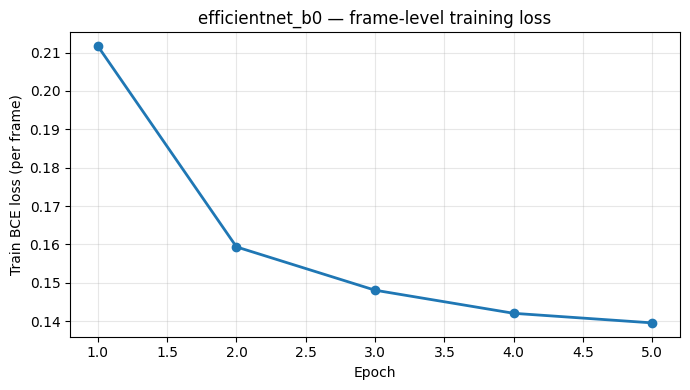

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
epochs_plot = [h["epoch"] for h in epoch_history]
losses_plot = [h["train_loss"] for h in epoch_history]
ax.plot(epochs_plot, losses_plot, marker="o", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Train BCE loss (per frame)")
ax.set_title(f"{BACKBONE} — frame-level training loss")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / f"train_loss_{BACKBONE}.png")
plt.show()

### Video-level ROC curve

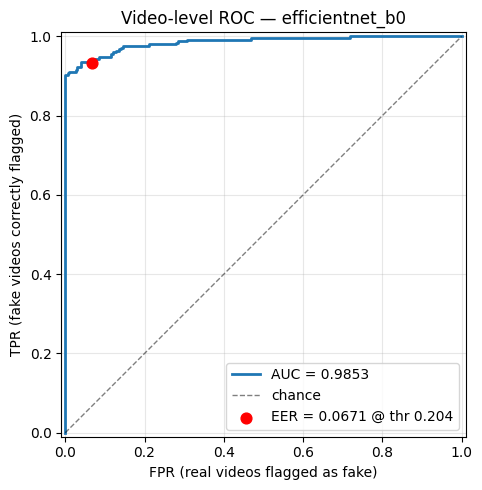

In [25]:
fpr_plot, tpr_plot, _thr = roc_curve(y_true, y_score)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_plot, tpr_plot, linewidth=2, label=f"AUC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="chance")
ax.scatter([eer], [1 - eer], color="red", zorder=5, s=60,
           label=f"EER = {eer:.4f} @ thr {eer_thr:.3f}")
ax.set_xlabel("FPR (real videos flagged as fake)")
ax.set_ylabel("TPR (fake videos correctly flagged)")
ax.set_title(f"Video-level ROC — {BACKBONE}")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.set_aspect("equal")
fig.tight_layout()
fig.savefig(FIG_DIR / f"roc_curve_{BACKBONE}.png")
plt.show()

### Confusion matrix (EER threshold)

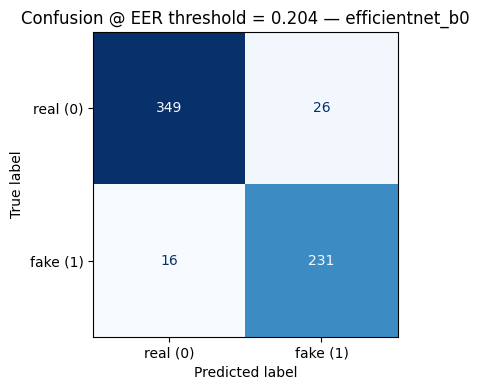

In [26]:
fig, ax = plt.subplots(figsize=(5, 4))
cm_array = np.array([[tn, fp], [fn, tp]])
cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm_array,
    display_labels=["real (0)", "fake (1)"],
)
cmd.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title(f"Confusion @ EER threshold = {eer_thr:.3f} — {BACKBONE}")
fig.tight_layout()
fig.savefig(FIG_DIR / f"confusion_{BACKBONE}.png")
plt.show()

### Per-source recall / specificity

`real` is reported as specificity (fraction of real videos correctly kept as real); the fake generators are reported as recall (fraction of that generator's videos correctly flagged fake).

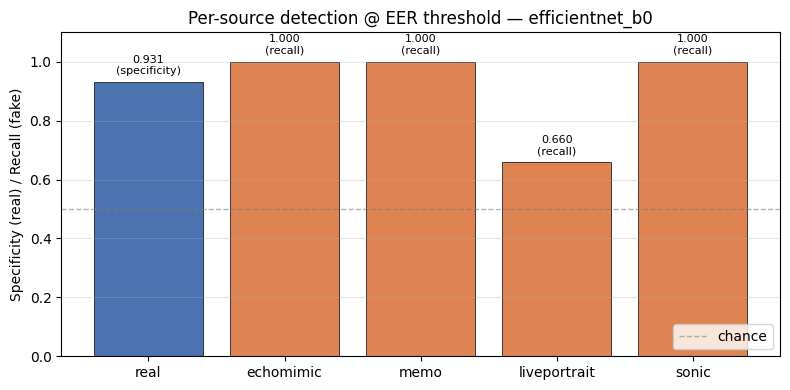

In [27]:
sources_order = ["real", "echomimic", "memo", "liveportrait", "sonic"]
values = [per_source_recall.get(s, float("nan")) for s in sources_order]
kinds = ["specificity" if s == "real" else "recall" for s in sources_order]
colors = ["#4c72b0" if s == "real" else "#dd8452" for s in sources_order]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(sources_order, values, color=colors, edgecolor="black", linewidth=0.5)
ax.set_ylim(0, 1.10)
ax.set_ylabel("Specificity (real) / Recall (fake)")
ax.set_title(f"Per-source detection @ EER threshold — {BACKBONE}")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.6, label="chance")
for bar, v, k in zip(bars, values, kinds):
    if v == v:  # not NaN
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                f"{v:.3f}\n({k})", ha="center", va="bottom", fontsize=8)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(FIG_DIR / f"per_source_recall_{BACKBONE}.png")
plt.show()

### Score distribution per class

A good detector separates the two histograms cleanly; a codec-shortcut detector will also show clean separation but tightly clustered near 0 and 1 (bimodal) rather than a smooth spread.

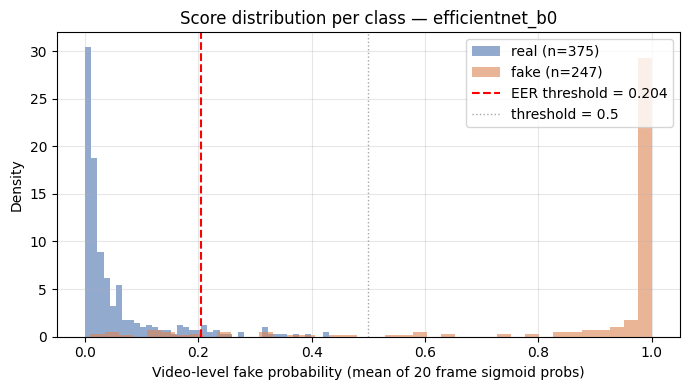

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(y_score[y_true == 0], bins=40, alpha=0.6,
        label=f"real (n={int((y_true == 0).sum())})",
        color="#4c72b0", density=True)
ax.hist(y_score[y_true == 1], bins=40, alpha=0.6,
        label=f"fake (n={int((y_true == 1).sum())})",
        color="#dd8452", density=True)
ax.axvline(eer_thr, color="red", linestyle="--", linewidth=1.5,
           label=f"EER threshold = {eer_thr:.3f}")
ax.axvline(0.5, color="grey", linestyle=":", linewidth=1, alpha=0.7,
           label="threshold = 0.5")
ax.set_xlabel("Video-level fake probability (mean of 20 frame sigmoid probs)")
ax.set_ylabel("Density")
ax.set_title(f"Score distribution per class — {BACKBONE}")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / f"score_distribution_{BACKBONE}.png")
plt.show()

### Score distribution per source folder

Splits the score-distribution view by generator, so you can see which fake generators the model handles vs which it struggles with. Different clusters at wildly different modes is another codec-shortcut smell.

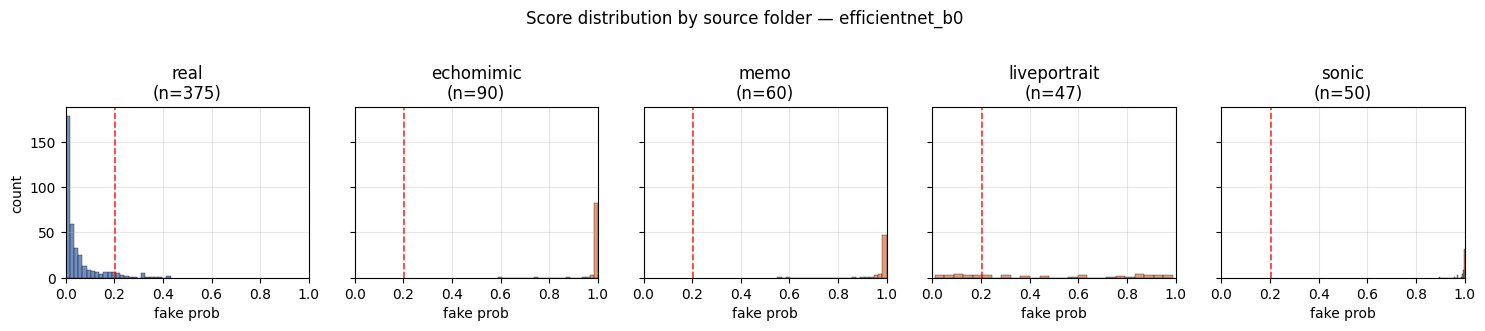

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3.2), sharey=True)
source_by_video = {vid: video_sources[vid] for vid in video_ids}
source_arr = np.array([source_by_video[v] for v in video_ids], dtype=object)

for ax, src in zip(axes, sources_order):
    mask = source_arr == src
    if not mask.any():
        ax.set_title(f"{src}\n(no videos)")
        continue
    color = "#4c72b0" if src == "real" else "#dd8452"
    ax.hist(y_score[mask], bins=25, color=color, alpha=0.8,
            edgecolor="black", linewidth=0.3)
    ax.axvline(eer_thr, color="red", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.set_title(f"{src}\n(n={int(mask.sum())})")
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("count")
for ax in axes:
    ax.set_xlabel("fake prob")
fig.suptitle(f"Score distribution by source folder — {BACKBONE}", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / f"score_distribution_by_source_{BACKBONE}.png")
plt.show()

## Interpretation cues

Read the results carefully:

- **Codec-shortcut caveat.** If the audit cell above reported disjoint signatures per source folder, treat any high AUC skeptically. A CNN trained on raw h.264 frames at 224×224 can pick up the encoder's ringing and blocking patterns, aspect-ratio rescaling artifacts, and DCT-quantization noise long before it learns "does this face look generated". The audio pipeline had the same problem — WavLM saturated at val ROC-AUC = 1.0 because TTS engines leave spectral fingerprints. We only fixed that with the codec-matched WAV pass (`src/data/codec_match_audio.py`). The visual analog is out of scope for this notebook.
- **`per_source_recall_or_specificity["real"]`** is *specificity* on real videos (fraction of real videos correctly not flagged). Everything else is recall of the fake class within that source folder.
- If `roc_auc` looks high (> 0.99) with `real` specificity < 0.5, the model is memorizing something surface-level about the fake generators rather than learning "this face is real". Cross-check by sampling a few false positives.
- Compare per-generator recall: if `echomimic` and `memo` are near 1.0 but `liveportrait` or `sonic` are much lower, that's the honest read on generalization across generators. The extended cap added `liveportrait` and `sonic`, so their per-source numbers are the true novelty check.
- **Cheap ablation to sanity-check the shortcut hypothesis.** Retrain with `transforms.RandomResizedCrop(224, scale=(0.5, 1.0))` + heavy `RandomHorizontalFlip` and `ColorJitter` on the training frames. If val AUC drops by ≥ 0.05, the initial number was mostly codec fingerprinting.